# Analiza eksploracyjna zbioru Chest X-rays (Indiana University)
źródło: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [35]:
DATASET_PATH = "../data/iu/"
CSV_NAME1 = "indiana_projections.csv"
CSV_NAME2 = "indiana_reports.csv"

In [36]:
proj = pd.read_csv(DATASET_PATH+CSV_NAME1, index_col=0)
reports = pd.read_csv(DATASET_PATH+CSV_NAME2, index_col=0)

---

In [37]:
proj.info()

<class 'pandas.DataFrame'>
Index: 7466 entries, 1 to 3999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    7466 non-null   str  
 1   projection  7466 non-null   str  
dtypes: str(2)
memory usage: 175.0 KB


In [38]:
proj.head()

,filename,projection
uid,,
1,1_IM-0001-4001.dcm.png,Frontal
1,1_IM-0001-3001.dcm.png,Lateral
2,2_IM-0652-1001.dcm.png,Frontal
2,2_IM-0652-2001.dcm.png,Lateral
3,3_IM-1384-1001.dcm.png,Frontal


In [39]:
proj.isna().sum()

filename      0
projection    0
dtype: int64

In [40]:
counts = proj.groupby('projection')['filename'].count()
counts

projection
Frontal    3818
Lateral    3648
Name: filename, dtype: int64

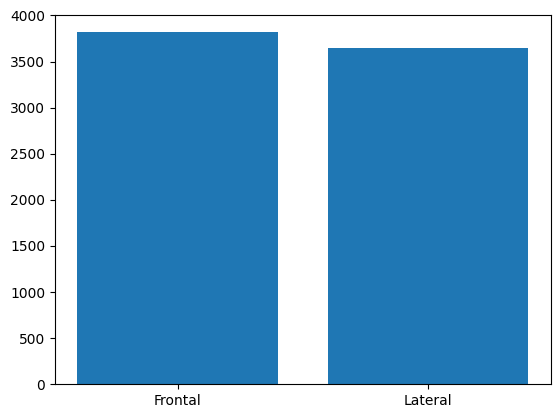

In [41]:
plt.figure(dpi=100)
plt.bar(counts.index, counts.values)
plt.show()

---

In [42]:
reports.info()

<class 'pandas.DataFrame'>
Index: 3851 entries, 1 to 3999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   MeSH        3851 non-null   str  
 1   Problems    3851 non-null   str  
 2   image       3851 non-null   str  
 3   indication  3765 non-null   str  
 4   comparison  2685 non-null   str  
 5   findings    3337 non-null   str  
 6   impression  3820 non-null   str  
dtypes: str(7)
memory usage: 240.7 KB


In [43]:
reports.head()

,MeSH,Problems,image,indication,comparison,findings,impression
uid,,,,,,,
1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [44]:
missing = reports.isna().sum().sort_values()

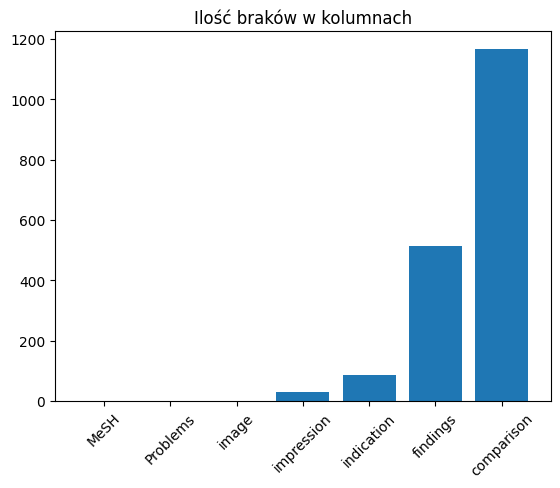

In [45]:
plt.figure(dpi=100)
plt.bar(missing.index,missing.values)
plt.title("Ilość braków w kolumnach")
plt.xticks(rotation=45)
plt.show()

In [46]:
categorical_columns = list(reports.columns)
categorical_columns.remove("findings")

In [47]:
d = {}
for cat in categorical_columns:
    d[cat] = reports[cat].value_counts().to_dict()


MeSH: {'normal': 1379, 'No Indexing': 92, 'Lung/hypoinflation': 44, 'Thoracic Vertebrae/degenerative/mild': 29, 'Thoracic Vertebrae/degenerative': 23}


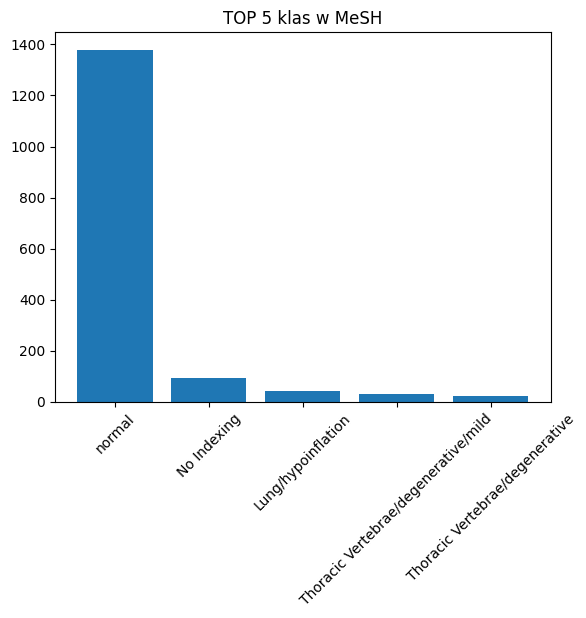

Problems: {'normal': 1379, 'No Indexing': 92, 'Lung': 86, 'Calcified Granuloma': 84, 'Thoracic Vertebrae': 59}


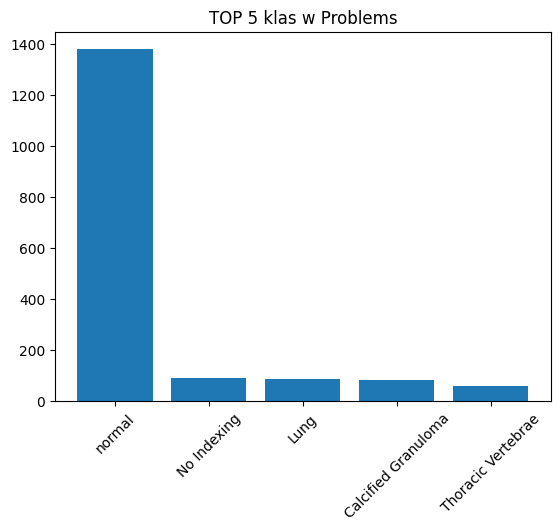

image: {'Xray Chest PA and Lateral': 1218, 'CHEST 2V FRONTAL/LATERAL ': 92, 'Chest, 2 views, frontal and lateral': 63, 'PA and lateral chest x-XXXX XXXX at XXXX hours. ': 52, 'CHEST 2V FRONTAL/LATERAL XXXX, XXXX XXXX PM ': 49}


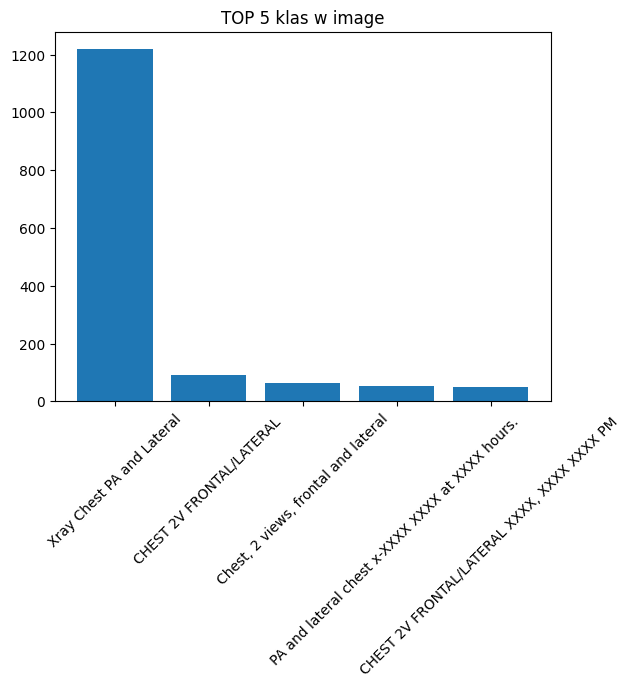

indication: {'Chest pain': 129, 'XXXX': 114, 'Chest pain.': 88, 'chest pain': 62, 'XXXX.': 58}


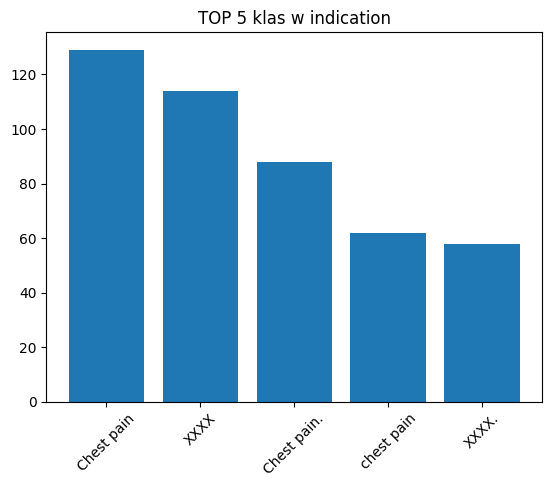

comparison: {'None.': 814, 'XXXX': 280, 'XXXX, XXXX.': 220, 'XXXX, XXXX': 159, 'None available.': 126}


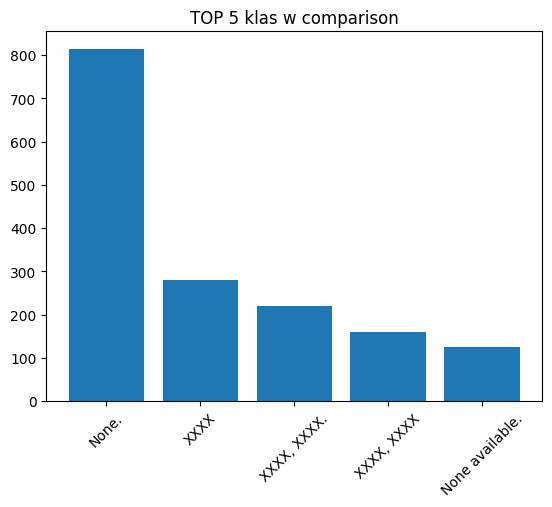

impression: {'No acute cardiopulmonary abnormality.': 301, 'No active disease.': 127, 'No acute cardiopulmonary abnormalities.': 112, 'No acute cardiopulmonary findings.': 111, 'No acute disease.': 109}


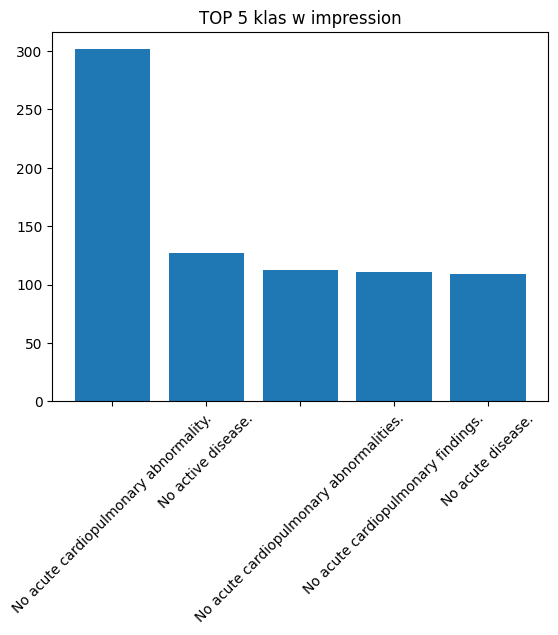

In [48]:
import itertools
for k,v in d.items():
    top_5_items = dict(itertools.islice(v.items(), 5))
    if not top_5_items:
        continue
    print(f"{k}: {top_5_items}")
    plt.figure(dpi=100)
    plt.bar(top_5_items.keys(), top_5_items.values())
    plt.xticks(rotation=45)
    plt.title(f"TOP 5 klas w {k}")
    plt.show()

---

### Analiza zmiennej opisywanej: `findings`

In [49]:
findings = reports['findings'].copy()
findings

uid
1       The cardiac silhouette and mediastinum size ar...
2       Borderline cardiomegaly. Midline sternotomy XX...
3                                                     NaN
4       There are diffuse bilateral interstitial and a...
5       The cardiomediastinal silhouette and pulmonary...
                              ...                        
3995    The cardiomediastinal silhouette and pulmonary...
3996    The lungs are clear. Heart size is normal. No ...
3997    Heart size within normal limits. Small, nodula...
3998                                                  NaN
3999                                                  NaN
Name: findings, Length: 3851, dtype: str

In [50]:
print(findings.isna().sum())

514


In [51]:
findings.dropna(inplace=True)

In [52]:
import re
from collections import Counter
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
all_tokens = []

for text in findings:
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    all_tokens.extend(filtered_tokens)

word_counts = Counter(all_tokens)

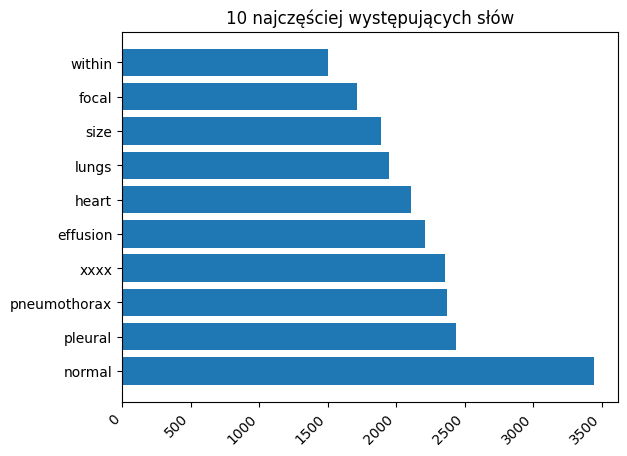

In [53]:
N=10
most_common = word_counts.most_common(N)
words = [item[0] for item in most_common]
counts = [item[1] for item in most_common]

plt.figure(dpi=100)
plt.barh(words, counts,)
plt.title("10 najczęściej występujących słów")
plt.xticks(rotation=45, ha="right")
plt.show()

Niepotrzebnym słowem jest `XXXX` użyte w celu anonimizacji pacjentów. W celu oczyszczenia danych usunę wszystkie jego wystąpienia.

In [54]:
findings = findings.str.replace(r'\s?XXXX', '', regex=True)

In [55]:
findings.head(10)

uid
1     The cardiac silhouette and mediastinum size ar...
2     Borderline cardiomegaly. Midline sternotomy. E...
4     There are diffuse bilateral interstitial and a...
5     The cardiomediastinal silhouette and pulmonary...
6     Heart size and mediastinal contour are within ...
7     The cardiac contours are normal. basilar atele...
8     The heart, pulmonary and mediastinum are withi...
9     The examination consists of frontal and latera...
10    The cardiomediastinal silhouette is within nor...
11    Cardiomediastinal silhouette and pulmonary vas...
Name: findings, dtype: str

Podsumowanie wykonanych operacji w celu oczyszczenia danych.

In [56]:
def clean(column):
    cleaned_column = column.copy()
    cleaned_column = cleaned_column.dropna()
    cleaned_column = cleaned_column.str.replace(r'\s?XXXX', '', regex=True)
    return cleaned_column

---

## Doprowadzenie zbioru do postaci [`id`, `obraz`, `raport`]
Zdecydowałem, żeby nie uwzględniać zdjęć bocznych, zbiór będzie uwzględniał jedynie zdjęcia typu `frontal`

In [62]:
final_csv = proj.copy()
final_csv = final_csv[proj['projection'] == "Frontal"]

In [63]:
final_csv = final_csv.drop("projection", axis=1)

In [66]:
final_csv = final_csv.join(findings, on=['uid'])

In [68]:
final_csv = final_csv.dropna()

In [70]:
final_csv.info()

<class 'pandas.DataFrame'>
Index: 3307 entries, 1 to 3997
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  3307 non-null   str  
 1   findings  3307 non-null   str  
dtypes: str(2)
memory usage: 77.5 KB


In [71]:
final_csv.to_csv("df.csv")